In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR

from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [ ]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 26 ,
    "attention" : True,
    "k":40,
    "batch_size" : 10,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "Attention7-DSV-tev-NewAugments",
    "deep_super_vision" : True,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = 7 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]

In [ ]:
# with open("./data/train_class_counts.json","r") as f:
#     train_class_counts = json.load(f)

# b = 0.999999

# counts = [0]*(len(train_class_counts))
# for k,v in train_class_counts.items():
#     counts[int(k)] = int(v)
# counts = np.array(counts,dtype=np.float64)

# f_alpha = (1-b)/(1-np.power(b,counts))
# f_alpha = f_alpha / f_alpha.sum()
# f_alpha[12] = 0.25
# # args["f_alpha"] = f_alpha.tolist()
# args["f_alpha"]=None
# args["f_alpha"]

In [ ]:
b=0.999
train_class_counts = [
    1200,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# f_alpha = (1-b)/(1-np.power(b,train_class_counts))
total = np.sum(train_class_counts)
f_alpha = np.log(total/np.array(train_class_counts))
f_alpha = (f_alpha / f_alpha.mean()).tolist()
f_alpha
args["f_alpha"] = f_alpha
f_alpha

[0.4192306623653949,
 0.7179025174767664,
 0.7172184312490237,
 0.7213506198648413,
 0.7718364322603585,
 0.6310175618202434,
 0.6310175618202434,
 0.7423200457906856,
 0.7659851796135413,
 0.8808365687040562,
 1.1472158488751967,
 1.4556618102528003,
 2.235638440011511,
 0.7578514761453713,
 1.1824730889495298,
 0.9906024194367986,
 0.7701509647332515,
 1.0385057663997224,
 1.238592452721393,
 1.3037247322439667,
 0.8402380298539683,
 1.2720560555504503,
 1.2438749107979519,
 1.3558847771047964,
 1.1742081741391486,
 0.9946054718189865]

In [ ]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [ ]:
train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    A.Downscale(
        scale_range=[0.7, 1],
        interpolation_pair={"downscale": 0, "upscale": 0},
        p=0.4
    ),
    A.GaussNoise(
        std_range=[0.0, 0.1],
        mean_range=[0, 0],
        per_channel=True,
        noise_scale_factor=1,
        p=0.4
    ),
    A.GaussianBlur(
        sigma_limit=[1.0,1.5],
        blur_limit = (3,7),
        p=0.4
    ),
    
    A.RandomBrightnessContrast(
        brightness_limit=(-0.15, 0.15 ),
        contrast_limit=(-0.15, 0.15 ),  
        brightness_by_max=True,
        p=0.3
    ),
    A.RandomGamma(
        gamma_limit=(90, 120), 
        p=0.3
    ),
    A.Affine(
        scale=(0.7, 1.4),  
        translate_percent=(0, 0),
        rotate=0,               
        shear=0,                 
        fit_output=False, 
        p=0.3
    ),
    A.Rotate(limit=30, p=0.4, fill_mask = 0),
    A.Rotate(limit=-30, p=0.4, fill_mask = 0),
    A.HorizontalFlip(p=0.4),
    A.VerticalFlip(p=0.4),
    A.Lambda(image=normalize_xca)
    ]
)
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    A.Lambda(image=normalize_xca),
    ToTensorV2()
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [ ]:

train_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "train")
valid_images = read_images(base_path = args["base_path"],preprocessor = train_preprocess,part = "val")

train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)

train_loader = DataLoader(
    train_ds,
    batch_size = args["batch_size"] ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=True
)
valid_loader = DataLoader(
    valid_ds,
    batch_size = args["batch_size"] ,
    num_workers = args["num_workers"] ,
    pin_memory=True,
    shuffle=False,
)

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# plot_some_images(train_images, train_transforms, image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [ ]:
model = nnUnet(args).to(args["device"])
loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=args["momentum"],
    lr=args["lr"],
    nesterov=True,
    weight_decay=args["weight_decay"]
)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

number of layers : 7
encoder settings :  [32, 64, 128, 256, 512, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 1024, 512, 256, 128, 64]
head settings :  26
loss is set to tversky


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.01
train ==> epcoh (0)
total loss : 3.207206332683563 - CE loss : 1.24570363342762 - tversky loss : 1.9615026748180389

train avg metrics for epoch 0 :
avg dice : 0.0008087331533238777 - avg precision : 0.0009878518337973219 - avg recall : 0.0017395957335520507
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.4011970639228821 - CE loss : 0.4093948170542717 - tversky loss : 0.9918022483587265

valid avg metrics for epoch 0 :
avg dice : 5.507787617913678e-13 - avg precision : 0.0 - avg recall : 0.0
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

...

current lr : 0.000426
train ==> epcoh (97)
total loss : 0.9047548049688339 - CE loss : 0.19721635356545447 - tversky loss : 0.7075384443998337

train avg metrics for epoch 97 :
avg dice : 0.49686165839482527 - avg precision : 0.4774374496936798 - avg recall : 0.5562897723913193
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (97)
total loss : 0.529991614818573 - CE loss : 0.1452997677028179 - tversky loss : 0.3846918553113937

valid avg metrics for epoch 97 :
avg dice : 0.43741936042922397 - avg precision : 0.42224267199635507 - avg recall : 0.4720678456127644
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

--- Total Norm ---
tensor(2.2363, device='cuda:0')
current lr : 0.0002958
train ==> epcoh (98)
total loss : 0.9171625208854676 - CE loss : 0.1953193439543247 - tversky loss : 0.7218431693315506

train avg metrics for epoch 98 :
avg dice : 0.5000448644166117 - avg precision : 0.4738083148002625 - avg recall : 0.55681121468544
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (98)
total loss : 0.5176930367946625 - CE loss : 0.14089015498757362 - tversky loss : 0.3768028780817986

valid avg metrics for epoch 98 :
avg dice : 0.44496494717913526 - avg precision : 0.43978627502918244 - avg recall : 0.48213318645954134
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.0001585
train ==> epcoh (99)
total loss : 0.8975204801559449 - CE loss : 0.1927351576089859 - tversky loss : 0.7047853273153305

train avg metrics for epoch 99 :
avg dice : 0.5036936894064106 - avg precision : 0.48214941918849946 - avg recall : 0.5682903964817524
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (99)
total loss : 0.5220786273479462 - CE loss : 0.14176404513418675 - tversky loss : 0.3803145833313465

valid avg metrics for epoch 99 :
avg dice : 0.44350361316249554 - avg precision : 0.4309663964062929 - avg recall : 0.47351762415491977
1 => dice : 0.8144482970237732 p : 0.7894726991653442 , r : 0.8410558104515076
2 => dice : 0.7461763024330139 p : 0.7501462697982788 , r : 0.7422481775283813
3 => dice : 0.7738495469093323 p : 0.7239707112312317 , r : 0.8311098217964172
4 => dice : 0.6746476292610168 p : 0.6001255512237549 , r : 0.7703016996383667
5 => dice : 0.7793899774551392 p : 0.7847980856895447 , r : 0.7740559577941895
6 => di

Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 9/9 [00:00<00:00, 3085.06it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  4.26it/s]

processing ./temp_script.py


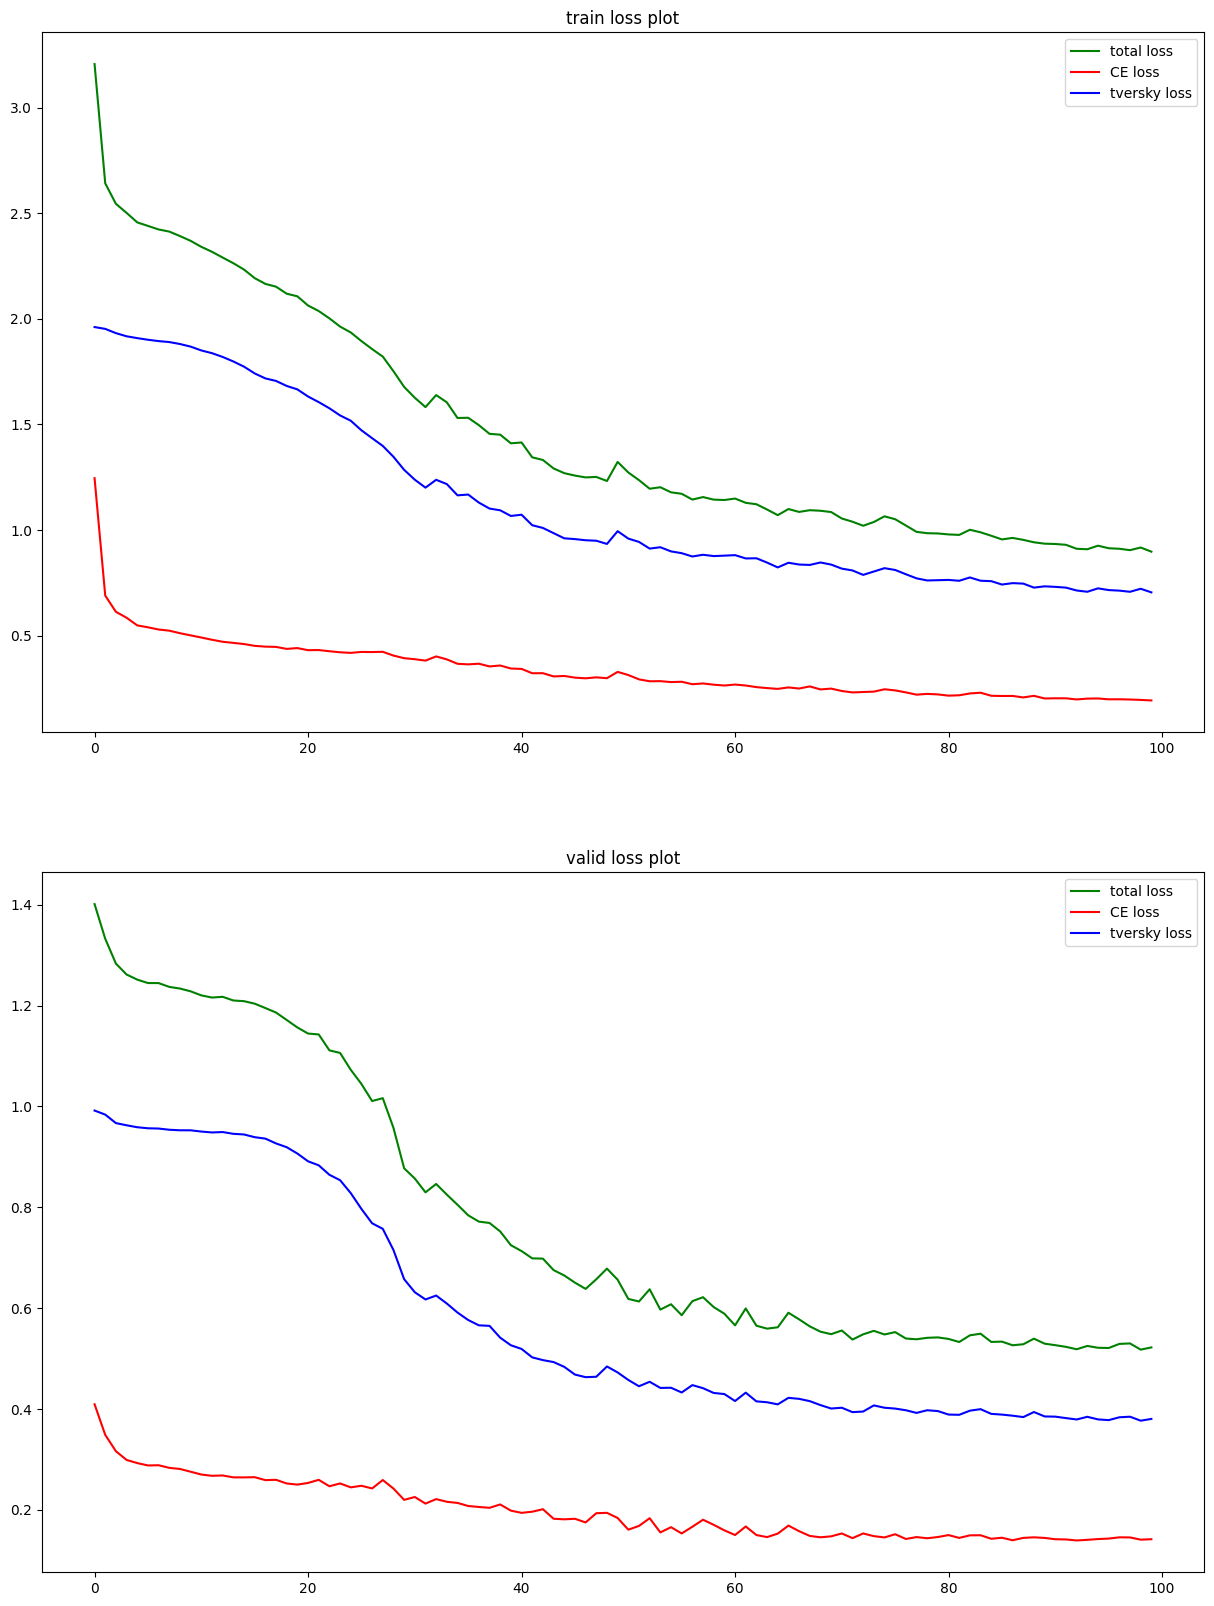

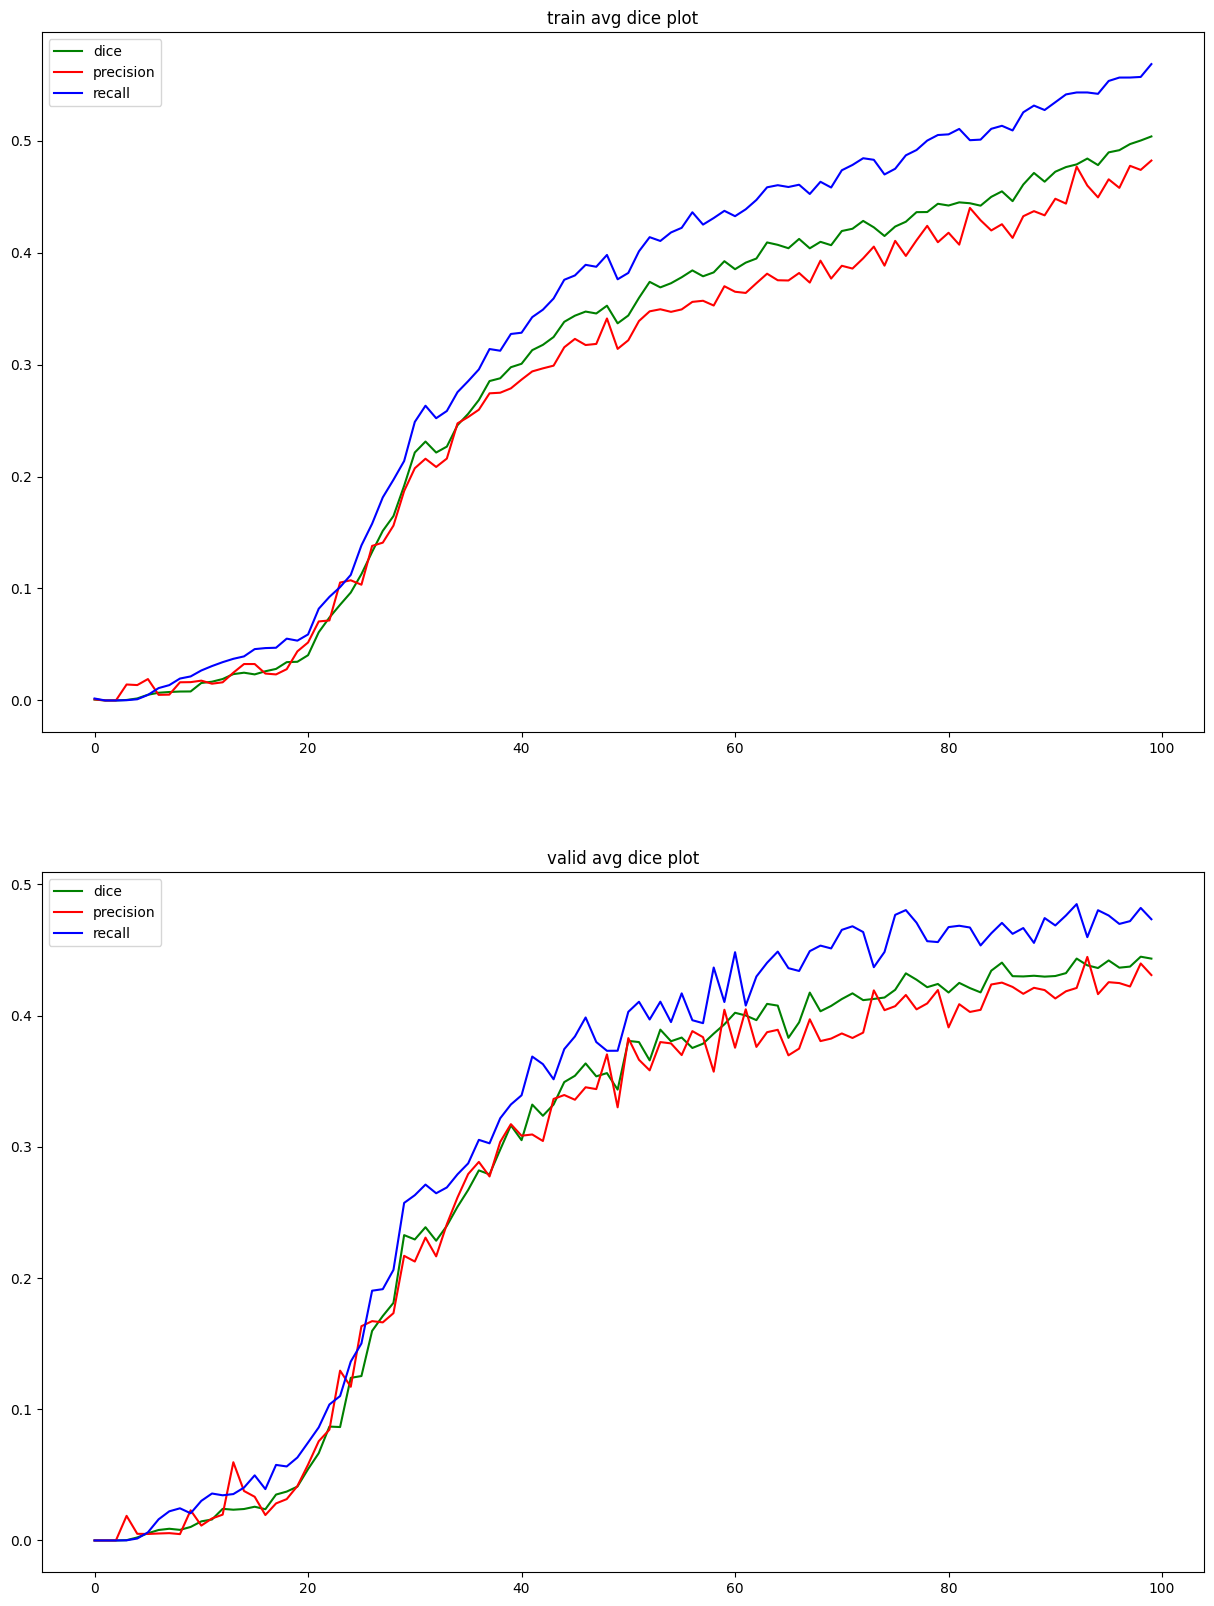

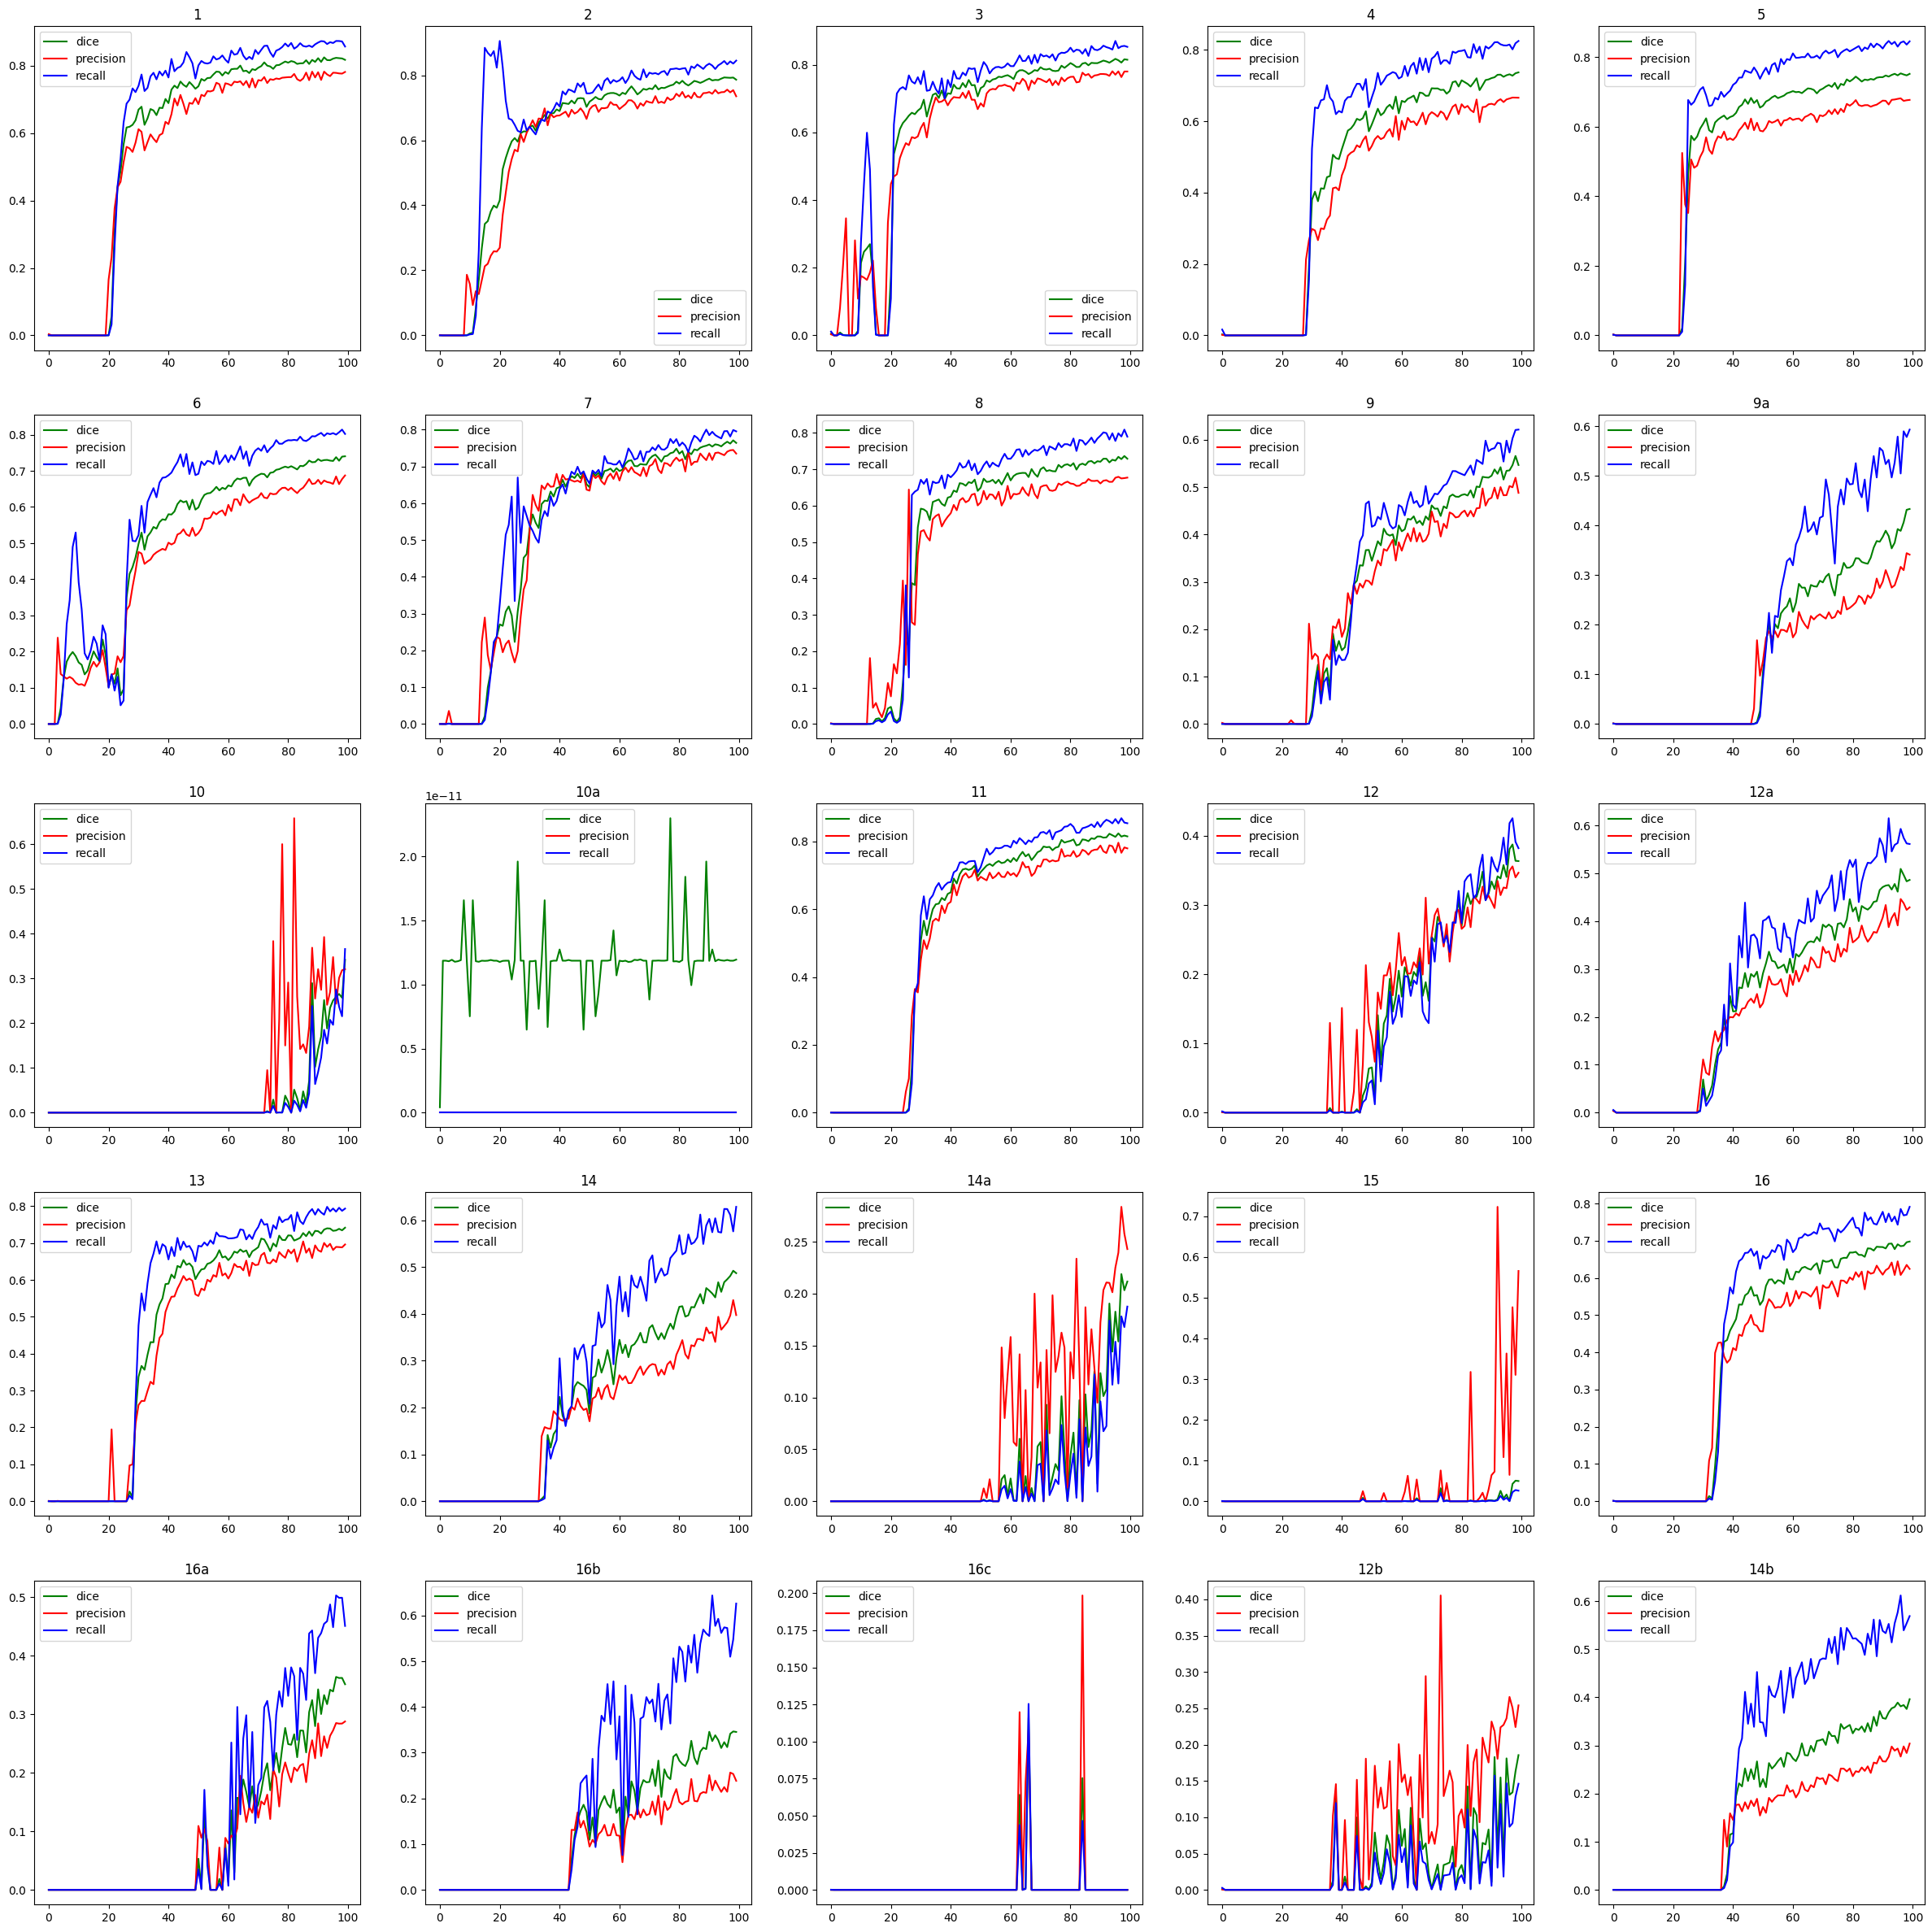

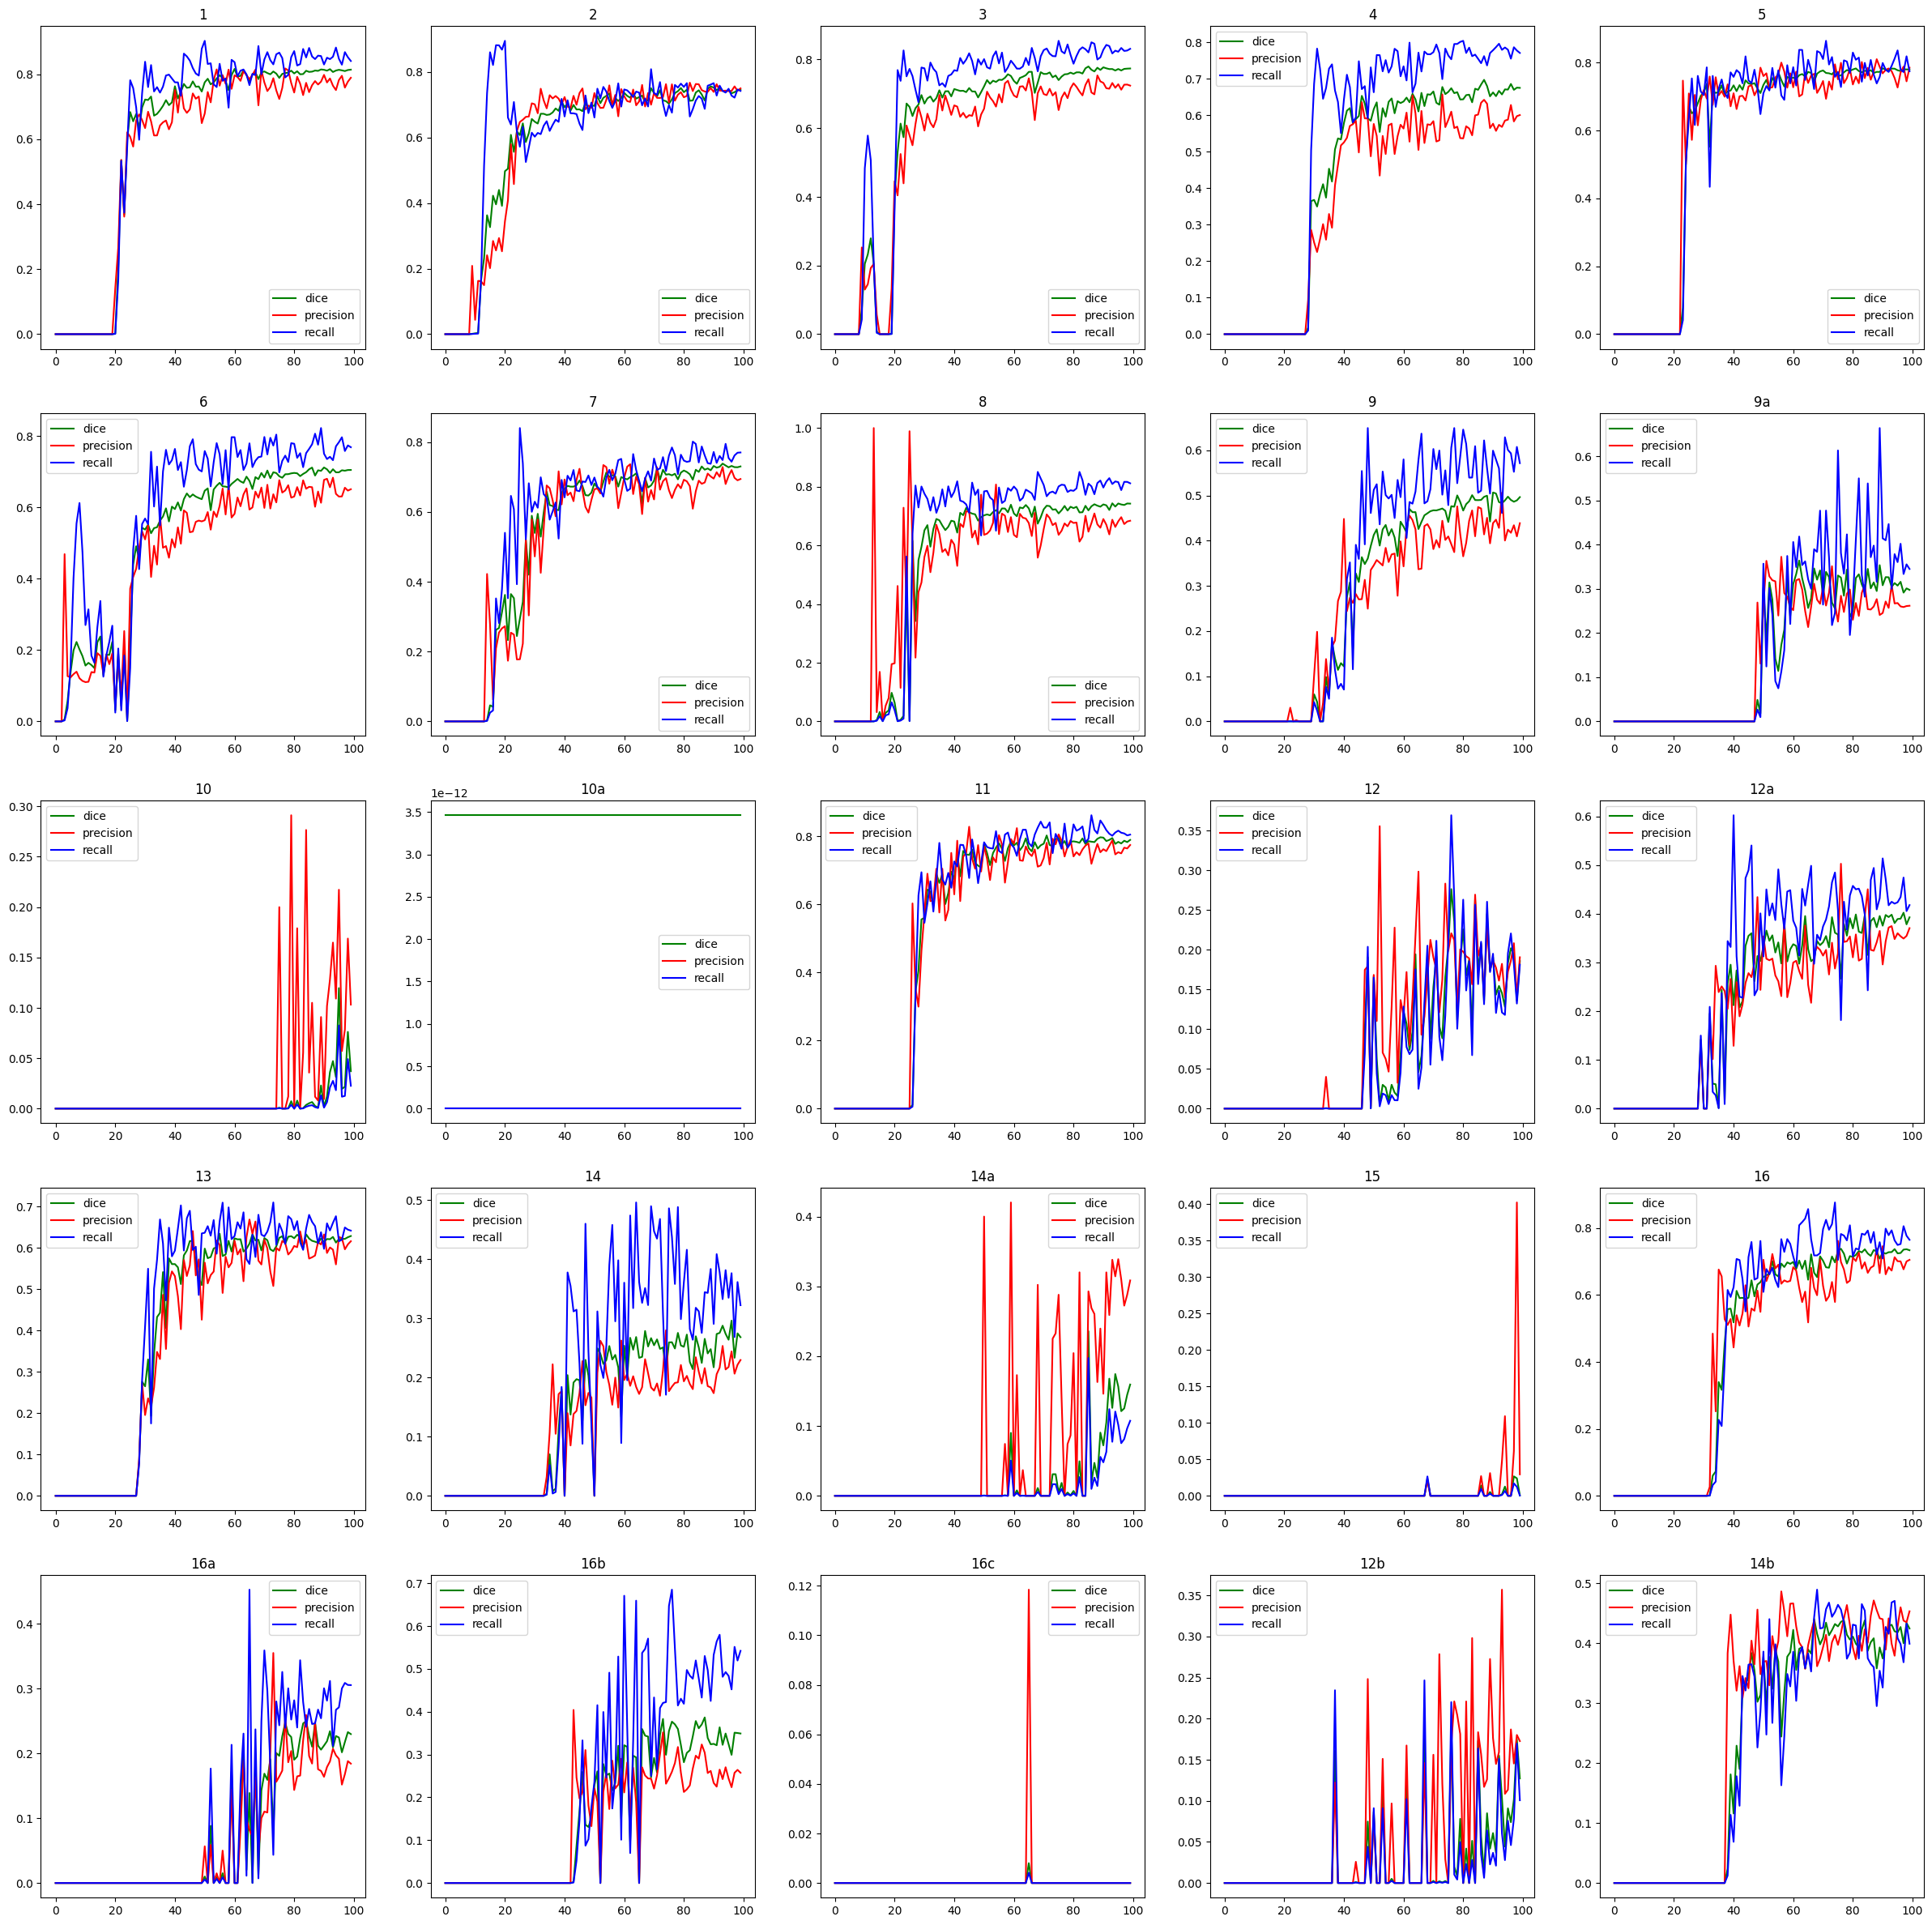

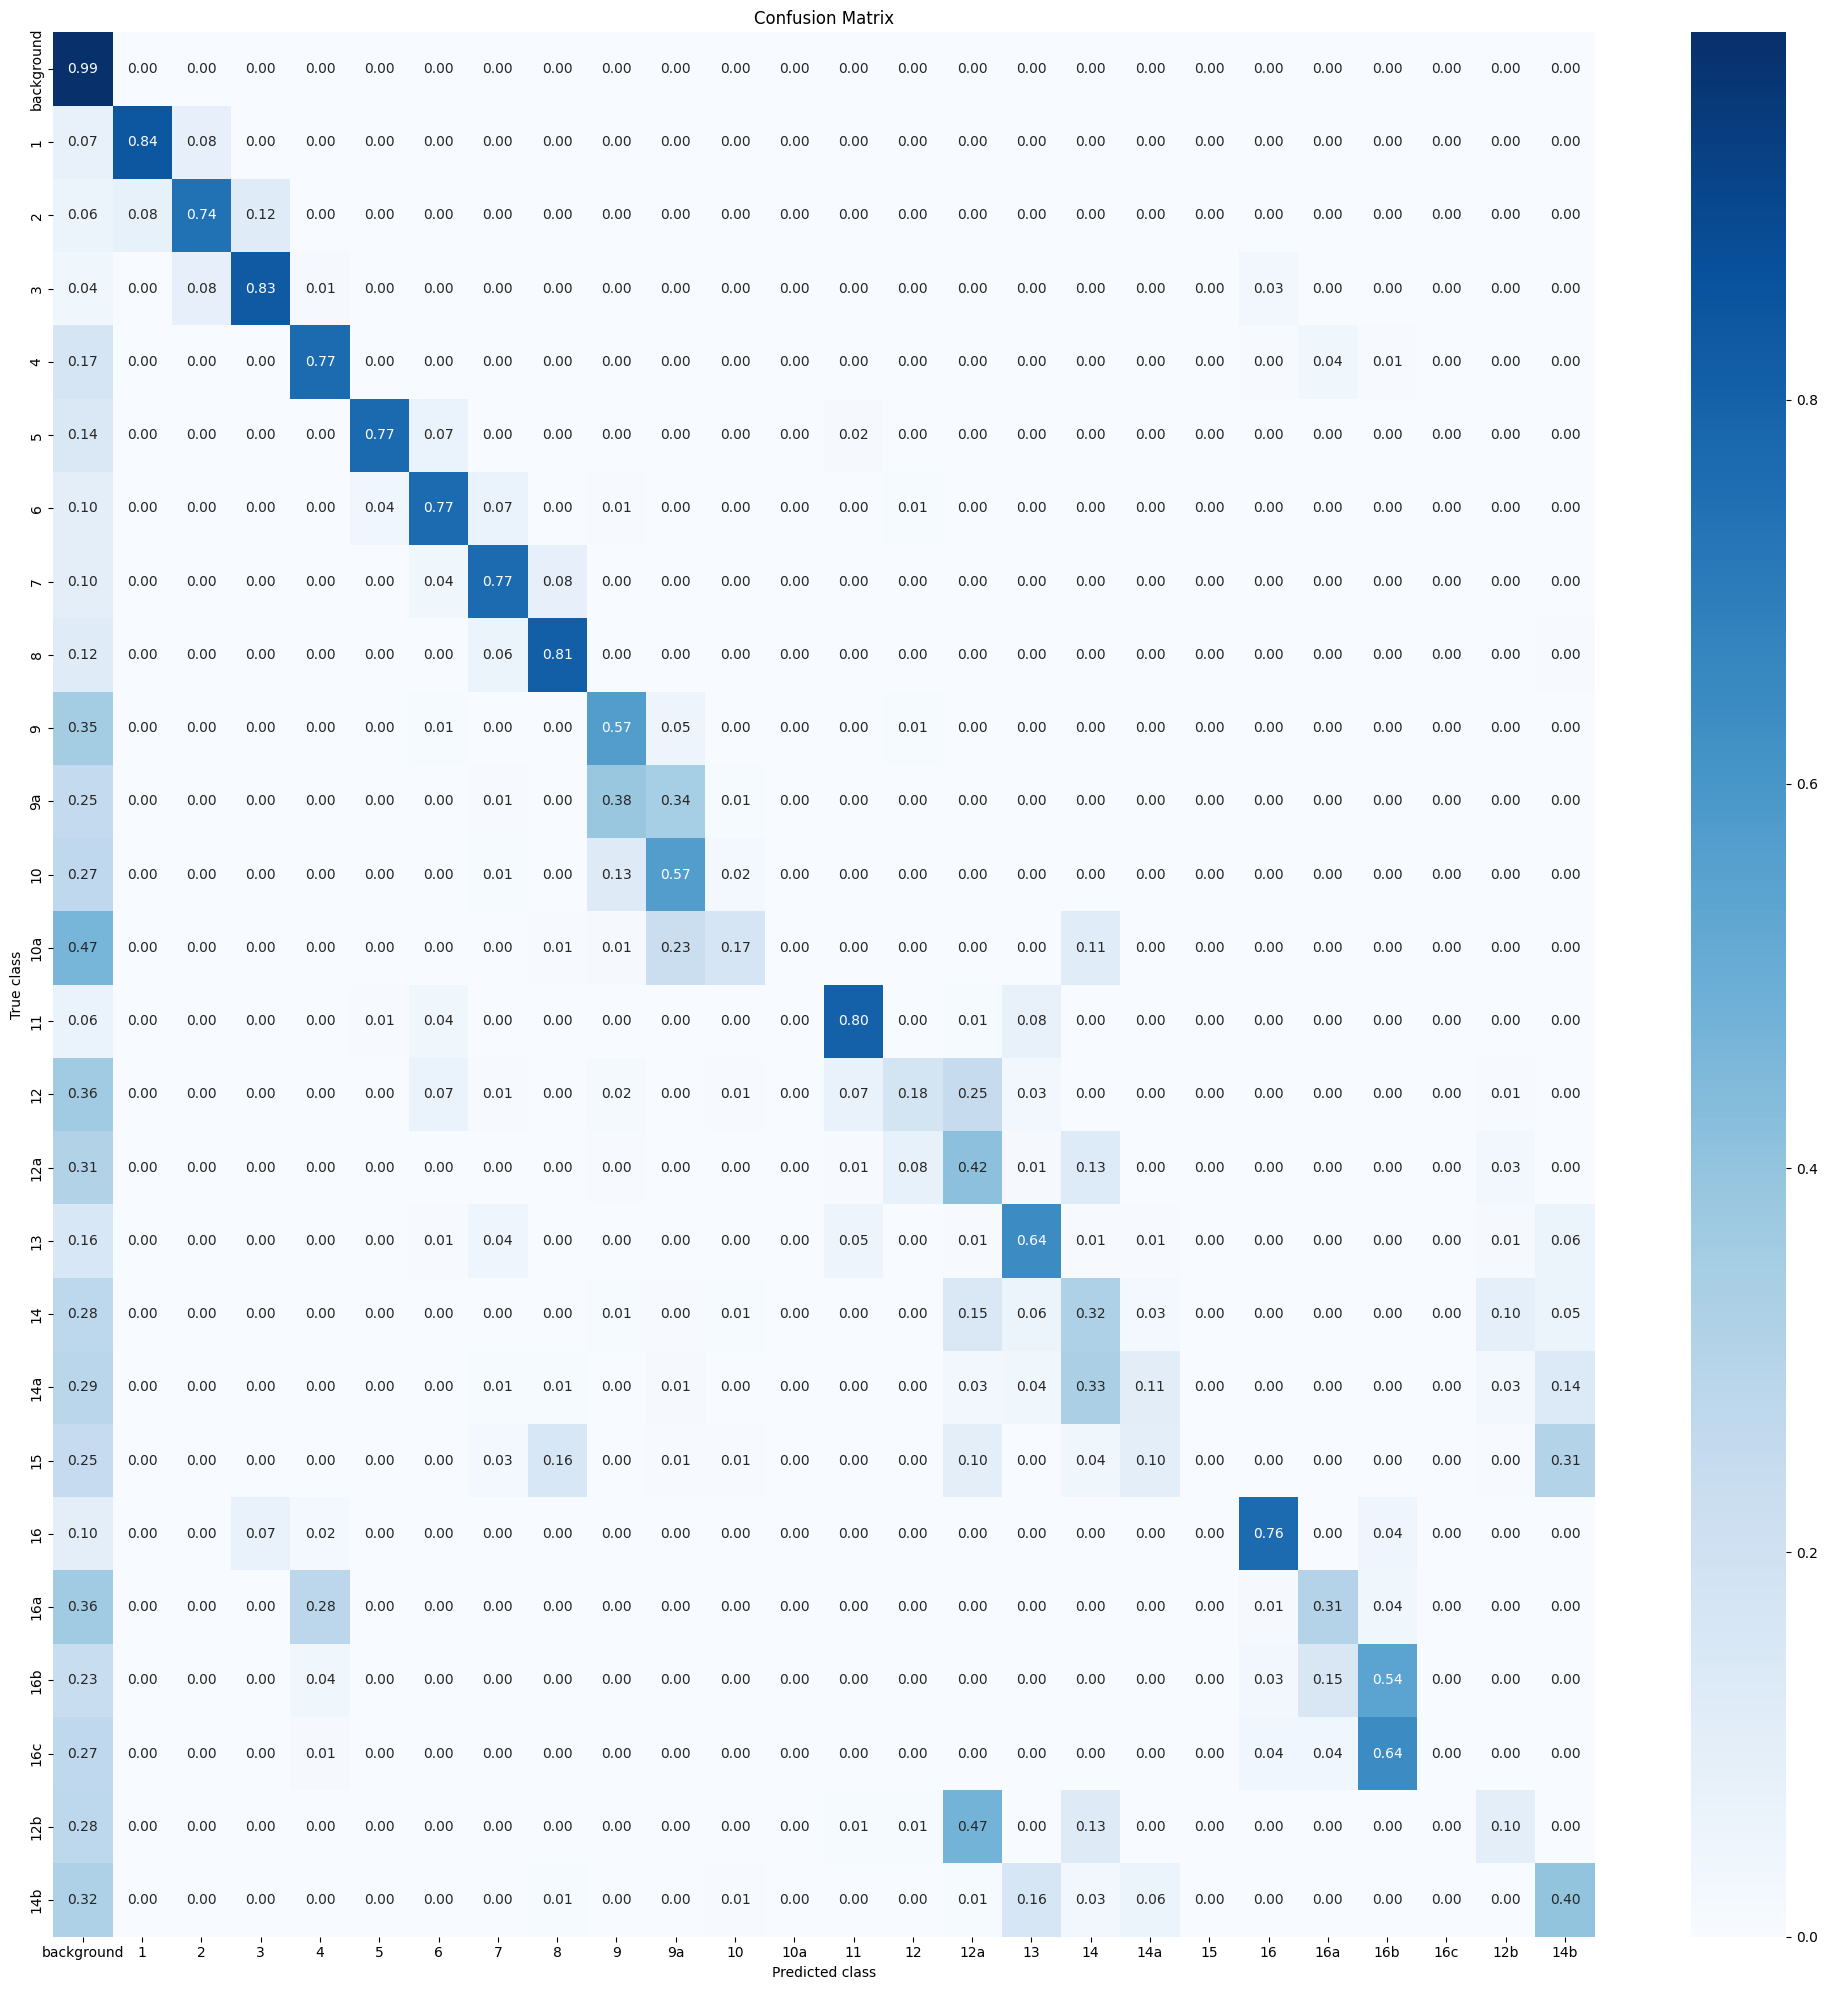

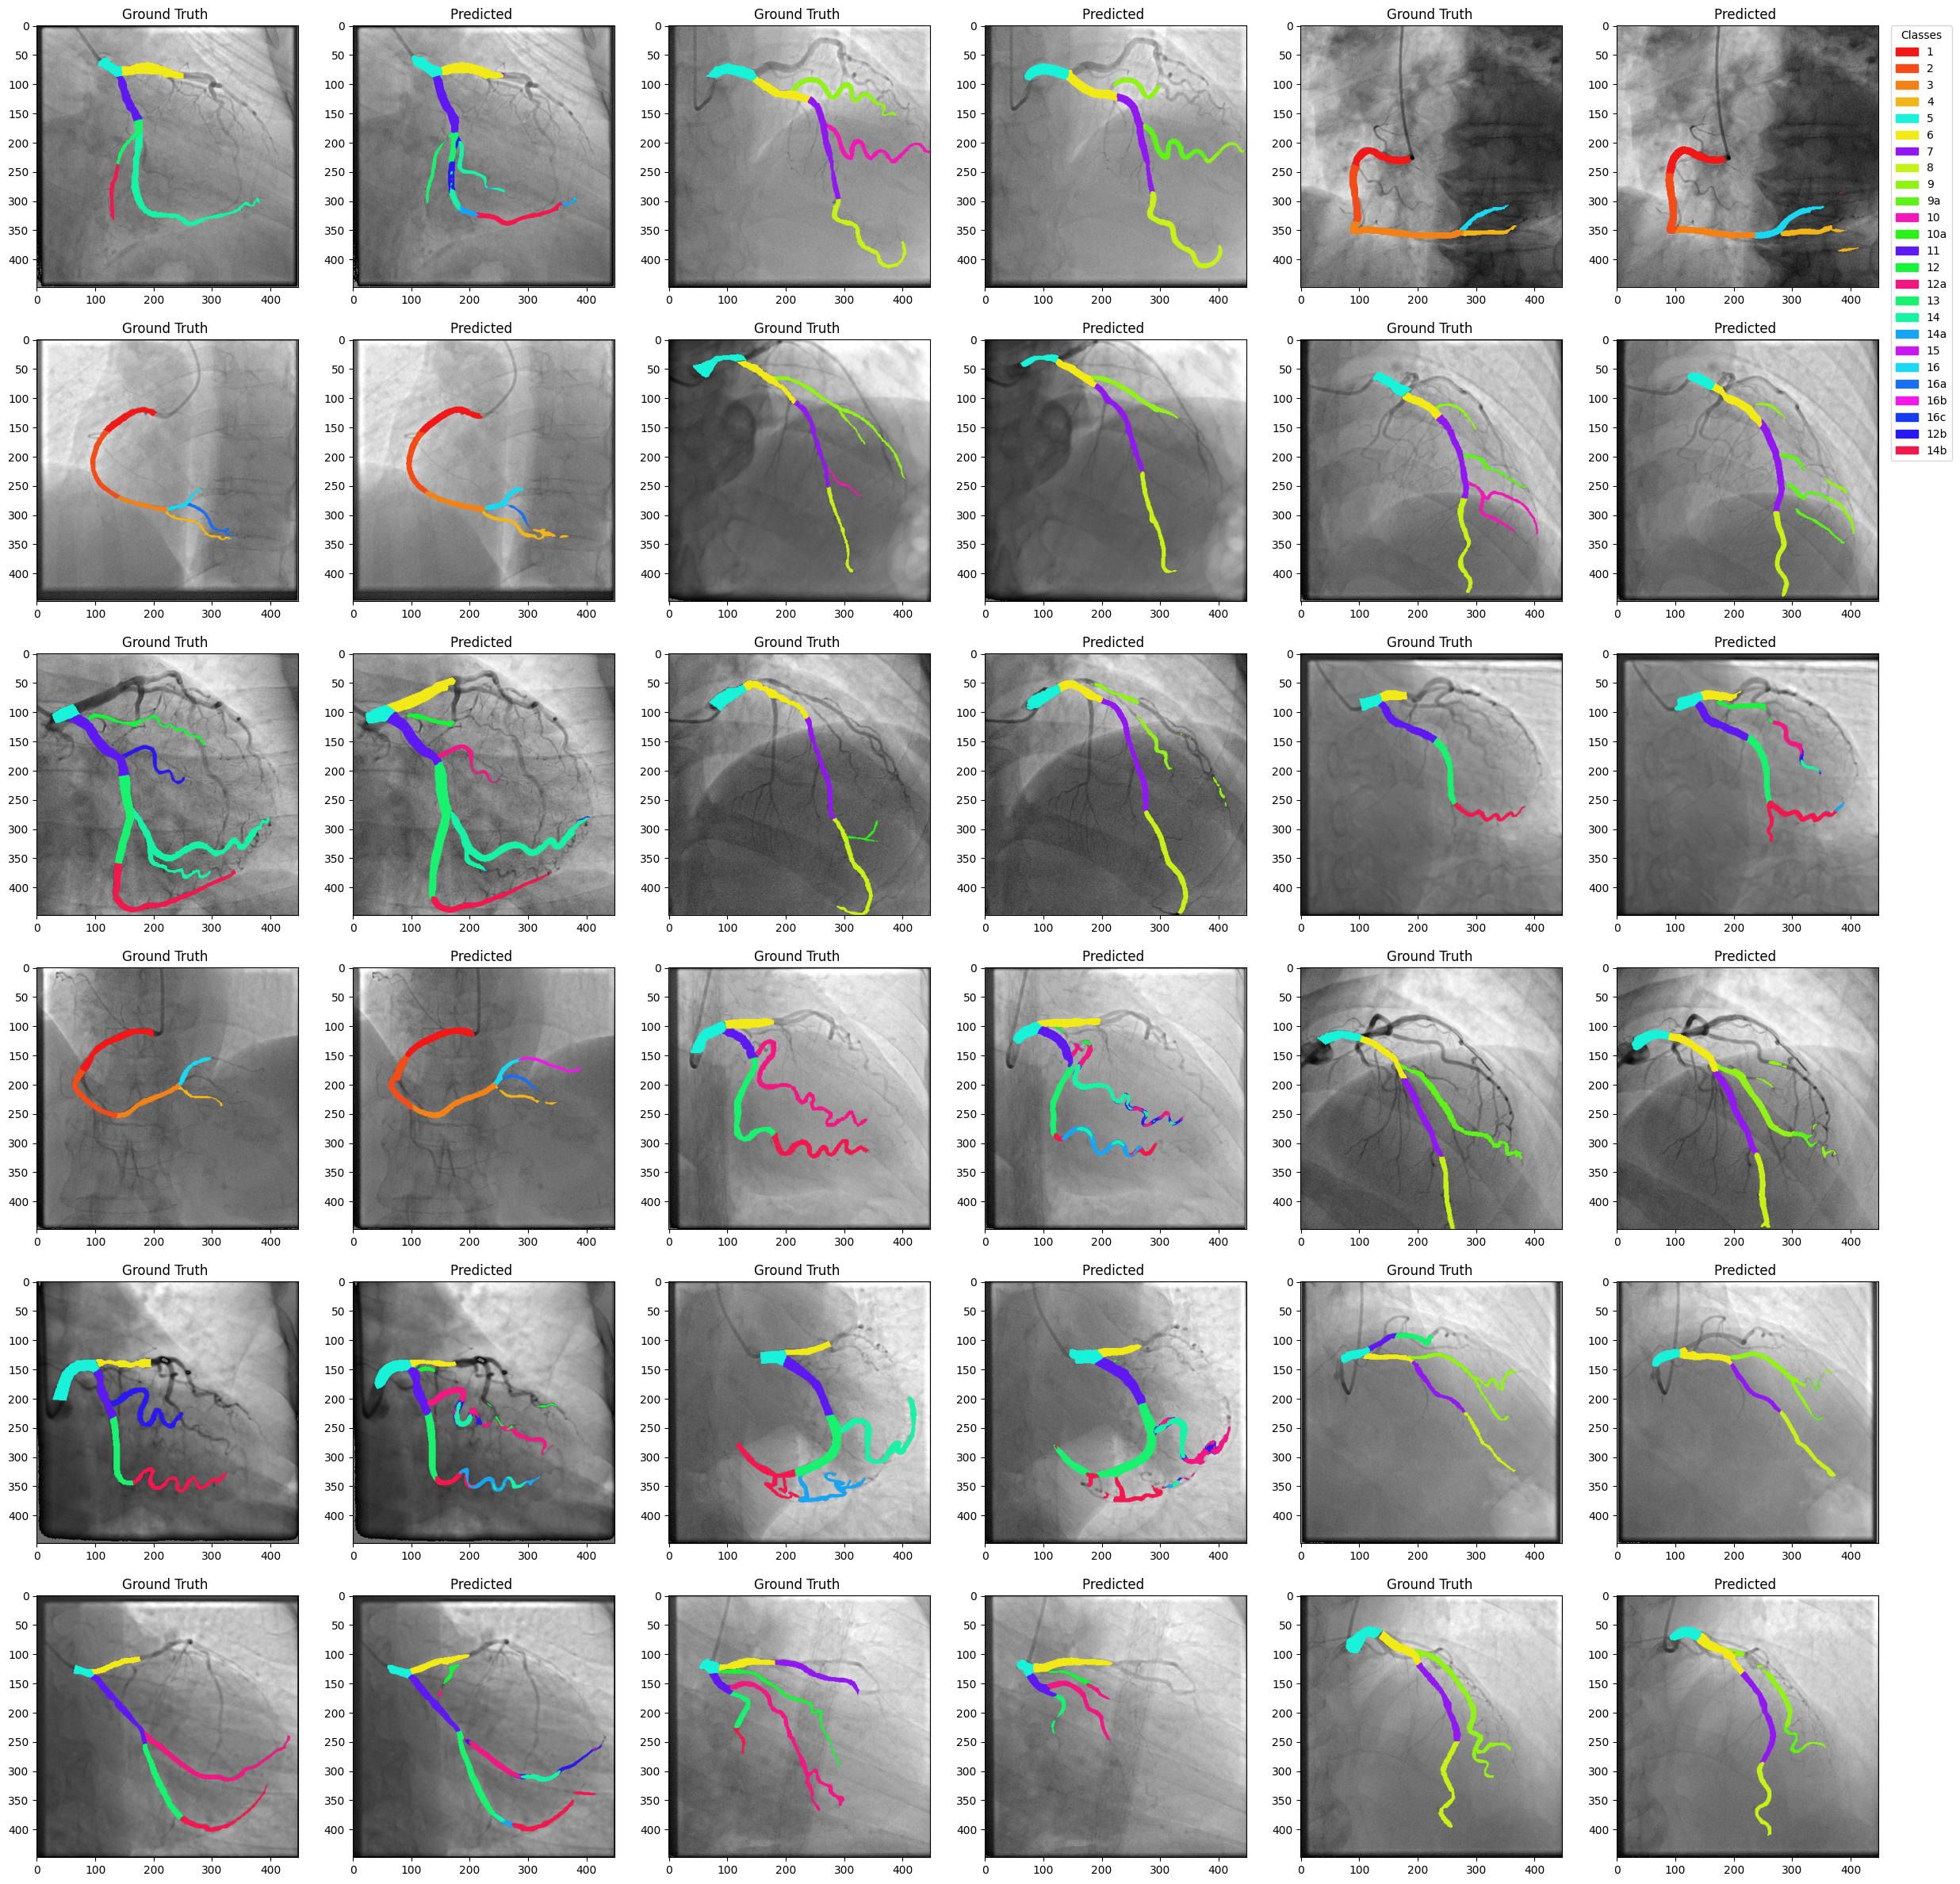

In [ ]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)